In [13]:
import json
from itertools import product
from pathlib import Path

import numpy as np
import numpy.typing as npt
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data
from loguru import logger
from torchmetrics.classification import BinaryF1Score
from tqdm import tqdm

from fast_boolean_analysis import FourierSeries, fourier_expand
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
from lattice_boolean_analysis import (
    AmplitudeMedianBinSignalKind,
    LBFFromNN,
    LBFFromSpinSystem,
    SignalKind,
    SignSignalKind,
)
from pytorchtools import EarlyStopping
from spin_lattices import KagomeLattice, SpinLattice, SquareLattice, TriangleLattice
from spin_nn import FC1SpinNN, SpinNN
from utils import get_abslargest_terms, make_unpacked_configurations
from multi_nn_2023_03_06 import (
    ground_state_cache_dir,
    experiment_dir,
    nn_checkpoints_dir,
    model_evaluation_dir,
    nn_terms_dir,
    system_terms_dir,
    eps_trains,
    J2s,
    signal_kinds,
    lattices,
)
import seaborn as sns


In [14]:
%matplotlib inline

In [15]:
def json_dir_to_df(dir: Path) -> pd.DataFrame:
    return pd.DataFrame([json.loads(file.read_text()) for file in dir.glob("*")])


In [16]:
model_evaluation = json_dir_to_df(model_evaluation_dir)


In [17]:
model_evaluation


,J2,eps_train,accuracy_test,sign_overlap_test,f1_test,epoch,lattice,train_size,path,signal_kind
0,0.0,0.020,0.995988,0.982450,0.995928,301,SquareLattice6x4,54083,experiments/multi_nn_2023_03_06/nn_checkpoints...,sign
1,0.0,0.010,0.988896,0.985135,0.988713,301,TriangleLattice6x4,27042,experiments/multi_nn_2023_03_06/nn_checkpoints...,sign
2,0.0,0.010,0.998640,0.998090,0.998614,301,SquareLattice6x4,27042,experiments/multi_nn_2023_03_06/nn_checkpoints...,sign
3,0.0,0.005,0.986605,0.973788,0.986419,513,SquareLattice6x4,13521,experiments/multi_nn_2023_03_06/nn_checkpoints...,sign
4,0.0,0.005,0.973358,0.959064,0.972863,301,TriangleLattice6x4,13521,experiments/multi_nn_2023_03_06/nn_checkpoints...,sign


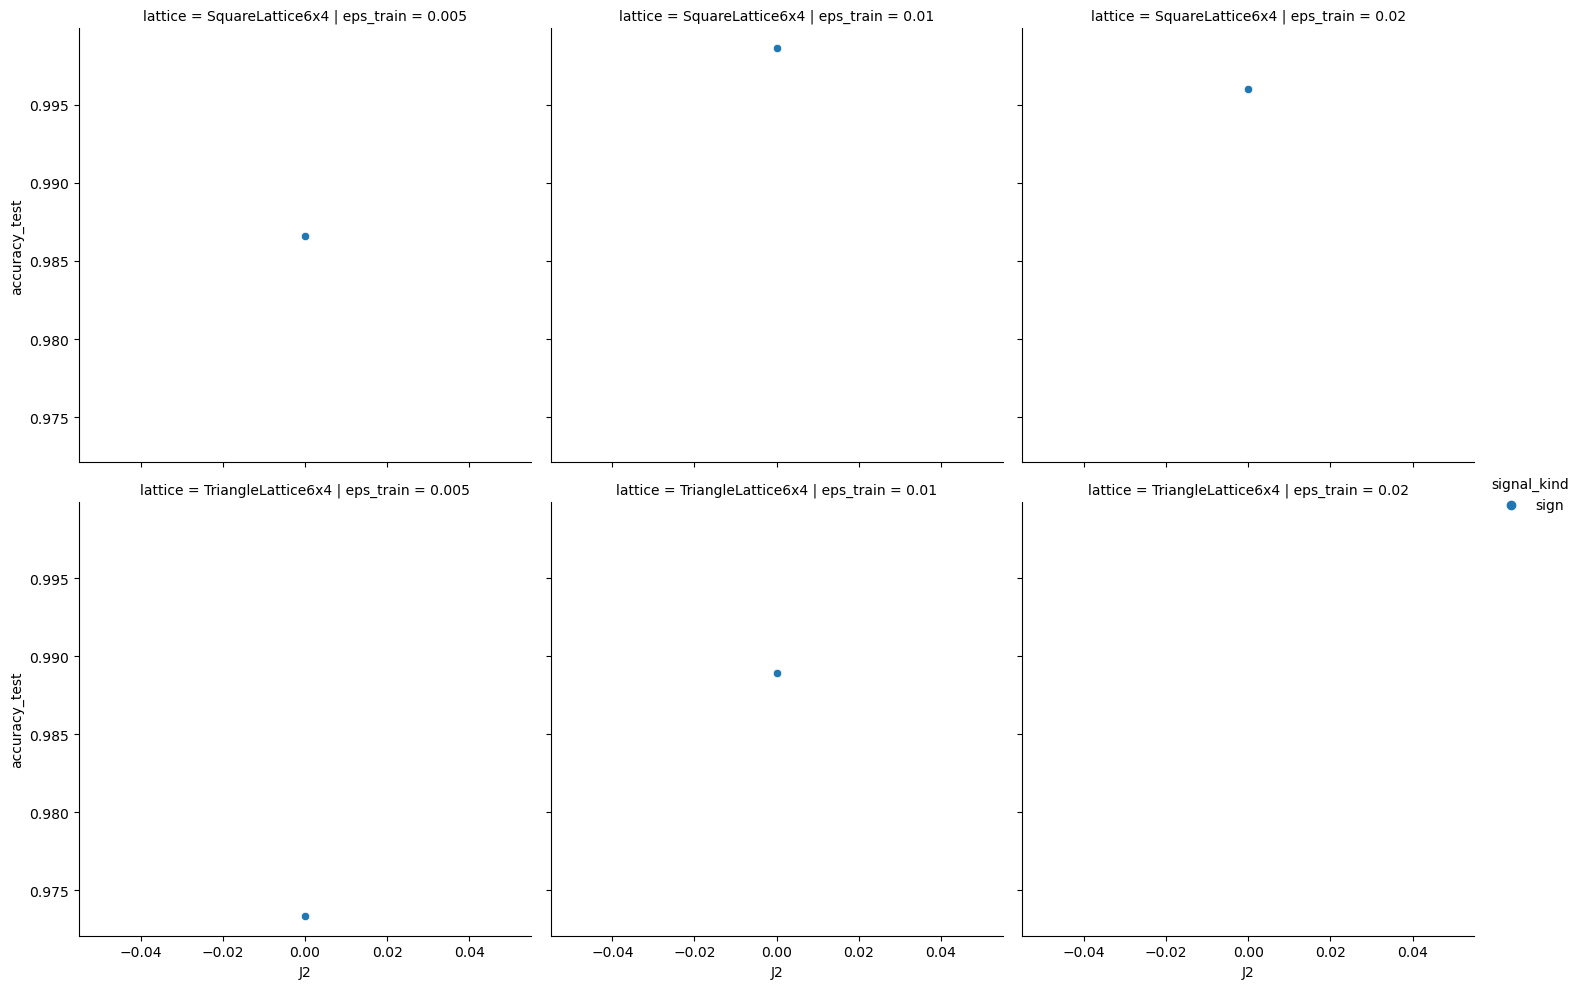

In [18]:
sns.relplot(model_evaluation, x="J2", y="accuracy_test", row="lattice", col="eps_train", hue="signal_kind")
